In [161]:
import networkx as nx
import random
import numpy as np
import time
#import matplotlib.pyplot as plt

In [162]:
VERBOSE = False

# Graph mutations functions

In [163]:
def delete_random_node(G):

    if len(G.nodes()) > 0:
        # Select a random node
        random_node = random.choice(list(G.nodes))
        # Remove the random node
        G.remove_node(random_node)

        if VERBOSE:
            print("Removed node:", random_node)

In [164]:
def add_random_node(G):
    # Creates a random node name
    name_node = str(len(G.nodes()) + 1)
    # Checks if node name already exists in graph
    while name_node in G.nodes():
        name_node = str(int(name_node) + 1)
    
    type_n = random.sample(list(DICT_SHAPE_TYPE.keys()), 1)[0]

    G.add_node(name_node, shape=type_n)
    
    if VERBOSE:
        print("Created a new node: ", name_node)


In [165]:
def add_random_edge(G):
    # Select two random nodes
    random_edge = random.sample(list(G.nodes), 2)

    # Checks if edge already exists
    while G.has_edge(random_edge[0], random_edge[1]):
        random_edge = random.sample(list(G.nodes), 2)
    
    # Determines the random action
    # TODO use only allowed types edges --> by now it does not matter as edge type is not considered
    type_e = random.sample(list(DICT_EDGE_TYPE.keys()), 1)[0]

    # Create the new edge
    G.add_edge(random_edge[0], random_edge[1], action=type_e)
    
    if VERBOSE:
        print("Created a new edge: (", random_edge[0], ",", random_edge[1], ")")


In [166]:
def delete_random_edge(G):
    if len(G.edges()) > 0:
     # Select a random edge
        random_edge = random.choice(list(G.edges))
        # Remove the random edge
        G.remove_edge(random_edge[0], random_edge[1])
        
        if VERBOSE:
            print("Removed edge: (", random_edge[0], random_edge[1], ")")

In [167]:
def change_direction_edge(G):
    if len(G.edges()) > 0:
        # Select a random edge
        random_edge = random.choice(list(G.edges))
        # Remove the random edge
        act = nx.get_edge_attributes(G, "action")
        G.remove_edge(random_edge[0], random_edge[1])
        G.add_edge(random_edge[1], random_edge[0], action=act[(random_edge[0], random_edge[1])])
        
        if VERBOSE:
            print("Previous edge: (", random_edge[0], random_edge[1], ")")
            print("New edge: (", random_edge[1], ",", random_edge[0], ")")

In [180]:
def mute_graph(G, mutations_allowed, num_mutations=1):
    for i in range(num_mutations):
        if VERBOSE:
            print(str(i) + "-th mutation")
        random.seed(time.time())
        random_mutation = random.choice(mutations_allowed)
        random_mutation(G)

    """nodo_objetivo = list(G.nodes)[0]
    print(nodo_objetivo)
    # Seleccionamos la componente conexa a partir del nodo inicial    
    componente_fuertemente_conexa = next(cc for cc in nx.weakly_connected_components(G) if nodo_objetivo in cc)
    # Crear un subgrafo con la componente conexa
    subgrafo = G.subgraph(componente_fuertemente_conexa)
    subgrafo_alcanzable = nx.dfs_tree(G, source=nodo_objetivo)
    # Copiar atributos de nodos
    for nodo in subgrafo_alcanzable.nodes:
        if nodo in G.nodes:
            subgrafo_alcanzable.nodes[nodo].update(G.nodes[nodo])

    # Copiar atributos de aristas
    for u, v in subgrafo_alcanzable.edges:
        if G.has_edge(u, v):
            subgrafo_alcanzable.edges[u, v].update(G.edges[u, v])
    

    componente_mas_grande = max(nx.weakly_connected_components(G), key=len)

    # Crear el subgrafo correspondiente
    subgrafo_componente_grande = G.subgraph(componente_mas_grande).copy()"""


    # Inicializar variables para almacenar el DFS Tree más grande
    max_tree_size = 0
    largest_dfs_tree = None

    # Iterar sobre todos los nodos como posibles raíces
    for nodo in G.nodes:
        # Generar el DFS Tree desde el nodo actual
        dfs_tree = nx.dfs_tree(G, source=nodo)
        
        # Comparar el tamaño del árbol actual con el máximo registrado
        if len(dfs_tree.nodes) > max_tree_size:
            max_tree_size = len(dfs_tree.nodes)
            largest_dfs_tree = dfs_tree.copy()  #


    # Copiar atributos de nodos
    for nodo in largest_dfs_tree.nodes:
        if nodo in G.nodes:
            largest_dfs_tree.nodes[nodo].update(G.nodes[nodo])

    # Copiar atributos de aristas
    for u, v in largest_dfs_tree.edges:
        if G.has_edge(u, v):
            largest_dfs_tree.edges[u, v].update(G.edges[u, v])


    return largest_dfs_tree

# METRICS

In [169]:
def intersection_lists(or_lst2, or_lst1):
    lst1 = or_lst1.copy()
    lst2 = or_lst2.copy()
    comm_list = []
    for i in or_lst1:
        if i in lst2:
            comm_list.append(i)
            lst1.remove(i)
            lst2.remove(i)
    return comm_list

In [170]:
def calc_precision(G_base, G_candidate):
    """
    Calculate precision for node sets of two graphs.
    
    Parameters:
    G_base: Ground truth graph (networkx graph)
    G_candidate: Candidate graph generated by PIDS (networkx graph)
    
    Returns:
    Precision value (float)
    """
    
    set_G_base = [(node_id, G_base.nodes[node_id]) for node_id in G_base.nodes()]
    set_G_candidate = [(node_id, G_candidate.nodes[node_id]) for node_id in G_candidate.nodes()]
    
    common_nodes = intersection_lists(list(set_G_base), list(set_G_candidate))
    count_common_nodes = len(common_nodes)

    return count_common_nodes/len(G_candidate) if len(G_base) > 0 else 0.0

In [171]:
def calc_recall(G_base, G_candidate):
    """
    Calculate recall for node sets of two graphs.
    
    Parameters:
    G_base: Ground truth graph (networkx graph)
    G_candidate: Candidate graph generated by PIDS (networkx graph)
    
    Returns:
    Recall value (float)
    """
    set_G_base = [(node_id, G_base.nodes[node_id]) for node_id in G_base.nodes()]
    set_G_candidate = [(node_id, G_candidate.nodes[node_id]) for node_id in G_candidate.nodes()]

    common_nodes = intersection_lists(list(set_G_base), list(set_G_candidate))
    count_common_nodes = len(common_nodes)
    
    return count_common_nodes / len(G_base) if len(G_base) > 0 else 0.0

In [172]:

def calc_f1_score(G_base, G_candidate):
    """
    Calculate the F1-score given precision and recall.
    
    Parameters:
    precision: Precision value (float)
    recall: Recall value (float)
    
    Returns:
    F1-score (float)
    """
    precision = calc_precision(G_base, G_candidate)
    recall = calc_recall(G_base, G_candidate)
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

In [173]:
# Number of copies of the original graph
NUM_GRAPHS = 50
# Number of mutations per graph
NUM_MUTATIONS = 10

In [174]:
G = nx.read_gexf("graphs/grafo_kairos.gexf")
G_base = G.copy()

In [175]:
NAME_DS = "CUSTOM2"
path_graphs = "SDTED/Data/" + NAME_DS + "/"

In [176]:
IDS_AS_TYPES= True
DICT_SHAPE_TYPE = {
    "ellipse": "file",
    "rectangle": "process",
    "diamond": "connection"
}

DICT_EDGE_TYPE = {
    "create": 0,
    "read": 1,
    "open": 2,
    "connect": 3,
    "send": 4, 
    "receive": 5,
    "write": 6,
    "execute": 7
}
    
DICT_NODE_TYPE = {
    "file": 0,
    "process": 1,
    "connection": 2
}


In [177]:
# list_graphs must be an array of all the graphs that must be compared for getting distance matrixes
def write_SDTED_graphs(arr_graphs):
    # First of all, I have to perform a re-assignment of node ids, because with this methodology each node id is unique, even if they are from different graphs
    arr_nodes = []
    arr_graphs_aux = []
    # 1 because it has to start with 1 to correspond to the 1st line
    i = 1
    mapping = {}
    type_dict = {} 
    # We use it to store the history of all ids correspondences
    mapping_inverse = {}  

    for index, graph in enumerate(arr_graphs):

        for node in graph.nodes():
            mapping[node] = i
            mapping_inverse[i] = node
            d = nx.get_node_attributes(graph, "shape")
            type_dict[i] = DICT_SHAPE_TYPE[d[node]]
            i = i + 1
        H = nx.relabel_nodes(graph, mapping)
        if IDS_AS_TYPES:
            dict_graph = {}
            for node in H.nodes():
                dict_graph[node] = node
            nx.set_node_attributes(H, dict_graph, name="type")
        arr_graphs_aux.append(H)

    arr_graphs = arr_graphs_aux   

    open(path_graphs + NAME_DS + "_graph_indicator.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_graph_indicator.txt", "a") as f:
            for node in graph.nodes():
                # Index must start with 1
                f.write(str(index + 1) + '\n')
    
    open(path_graphs + NAME_DS +"_A.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_A.txt", "a") as f:
            for edge in graph.edges():
                # The i-th node corresponds to the i-th row (starting with 1).
                f.write(str(edge[0]) + ', ' + str(edge[1] ) + '\n')

    open(path_graphs + NAME_DS + "_edge_labels.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_edge_labels.txt", "a") as f:
            actions = nx.get_edge_attributes(graph, 'action')
            for edge in graph.edges():
                f.write(str(DICT_EDGE_TYPE[actions[(edge[0], edge[1])]]) + '\n')


    open(path_graphs + NAME_DS +"_node_labels.txt", "w")
    for index, graph in enumerate(arr_graphs):
        with open(path_graphs + NAME_DS + "_node_labels.txt", "a") as f:
            for node in graph.nodes():
                if IDS_AS_TYPES:
                    types = nx.get_node_attributes(graph, "type")
                    f.write(str(types[node]) + '\n')
                else:
                    shapes = nx.get_node_attributes(graph, "shape")
                    f.write(str(DICT_NODE_TYPE[DICT_SHAPE_TYPE[shapes[node]]]) + '\n')


    # New file type that stores the types of each id (to calculate the initial cost matrix)
    # The file consists of a dictionary separated with commas.  First col = id, second col = type
    if IDS_AS_TYPES:
        path_file = path_graphs + NAME_DS + "_node_types.txt"
        with open(path_file, "w") as f:
            for key_dict in type_dict.keys():
                f.write(str(key_dict) + ',' + str(DICT_NODE_TYPE[type_dict[key_dict]]) + '\n')
        
        path_file2 = path_graphs + NAME_DS + "_node_ids.txt"
        with open(path_file2, "w") as f:
            for key_dict in mapping_inverse.keys():
                f.write(str(key_dict) + ',' + str(mapping_inverse[key_dict]) + '\n')
    

    with open(path_graphs + NAME_DS + "_graph_labels.txt", "w") as f:
        for index, graph in enumerate(arr_graphs):
            f.write("1\n")

In [181]:
arr_mutations = [delete_random_node, delete_random_edge, change_direction_edge, add_random_node, add_random_edge]

arr_g_candidate = []
arr_precs = []
arr_recalls = []
arr_f1s = []

arr_g_candidate.append(G_base)
for graph in range(NUM_GRAPHS):
    G_candidate = G_base.copy()
    #print(len(G.nodes()), len(G.edges()))
    G_muted = mute_graph(G_candidate, arr_mutations, NUM_MUTATIONS)
    print(len(G_muted.nodes), len(G_muted.edges))
    #print(len(G.nodes()), len(G.edges()))
    arr_precs.append(calc_precision(G_base, G_muted))
    arr_recalls.append(calc_recall(G_base, G_muted))
    arr_f1s.append(calc_f1_score(G_base, G_muted))
    arr_g_candidate.append(G_muted)

arr_metrics = [arr_precs, arr_recalls, arr_f1s]
# We add the empty graph
arr_g_candidate.append(nx.DiGraph())
write_SDTED_graphs(arr_g_candidate)

18 17
18 17
22 21
20 19
16 15
13 12
7 6
16 15
15 14
10 9
9 8
18 17
16 15
16 15
17 16
10 9
17 16
17 16
16 15
14 13
8 7
13 12
13 12
15 14
11 10
17 16
12 11
11 10
11 10
20 19
16 15
13 12
9 8
17 16
9 8
9 8
11 10
16 15
14 13
8 7
11 10
18 17
11 10
11 10
12 11
13 12
10 9
12 11
15 14
11 10


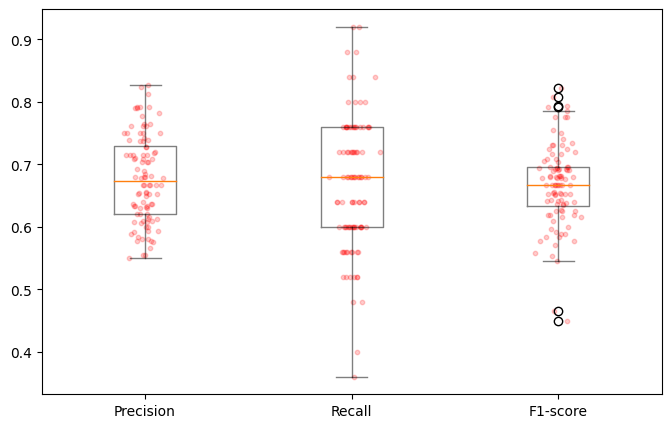

In [65]:
plt.style.use('default')
plt.figure(figsize=(8, 5))

box = plt.boxplot(arr_metrics, labels = ["Precision", "Recall", "F1-score"])

for element in ['boxes', 'whiskers', 'caps']:
    for item in box[element]:
        item.set_alpha(0.5) 

for index, metric in enumerate(arr_metrics):
    x = np.random.normal(index + 1, 0.04, size=len(metric))
    plt.scatter(x, metric, s=10, color='r', alpha=0.2)
#plt.set_yscale('log')
# Número de técnicas usadas por los gruposeach que \nhan usado al menos una técnica usada $N$ veces")
#plt.set_ylabel("num_groups_techniques($N$)")
#plt.set_xlabel("$N$")
plt.show()
#fig.savefig("Number of times each technique is used (boxplots).png")

# Flujo

# crear funcion de calculo de f1,prec,recall
# crear generaciones de n grafos con M mutaciones cada uno

# Añadir grafo vacío con tantos nodos como el inicial 
Alamcenar en una tabla las distancaias de cada n grafos (tabla nxn y coger la priomera col). 
Coger la max dist--> dist de ultima columna.
Normalizar y pasar a similitud

plot de metricas medias y de variacion